# Tutorial: ECT for example dataset

In [1]:
conda update conda

Retrieving notices: ...working... done
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.9.0
  latest version: 24.7.1

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=24.7.1



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


nest-asyncio-1.6.0   | 15 KB     | ##################################### | 100% 
tinycss2-1.2.1       | 40 KB     | ##################################### | 100% 
libidn2-2.3.4        | 157 KB    | ##################################### | 100% 
cython-3.0.10        | 3.0 MB    | ##################################### | 100% 
tenacity-8.2.3       | 47 KB     | ##################################### | 100% 
libabseil-20240116.2 | 1.1 MB    | ##################################### | 100% 
multidict-6.0.4      | 49 KB     | ##################################### | 100% 
unicodedata2-15.1.0  | 517 KB    | ##################################### | 100% 
idna-3.7             | 115 KB    | ##################################### | 100% 
conda-pack-0.7.1     | 51 KB     | ##################################### | 100% 
gensim-4.3.2         | 21.9 MB   | ##################################### | 100% 
pycurl-7.45.2        | 130 KB    | ##################################### | 100% 
cytoolz-0.12.2       | 338 K

soupsieve-2.5        | 72 KB     | ##################################### | 100% 
jedi-0.19.1          | 1.1 MB    | ##################################### | 100% 
nss-3.89.1           | 1.9 MB    | ##################################### | 100% 
lz4-c-1.9.4          | 167 KB    | ##################################### | 100% 
krb5-1.19.4          | 1.2 MB    | ##################################### | 100% 
libprotobuf-4.25.3   | 2.3 MB    | ##################################### | 100% 
zeromq-4.3.5         | 314 KB    | ##################################### | 100% 
python-dateutil-2.9. | 279 KB    | ##################################### | 100% 
yapf-0.40.2          | 380 KB    | ##################################### | 100% 
openjpeg-2.4.0       | 330 KB    | ##################################### | 100% 
blosc-1.21.3         | 61 KB     | ##################################### | 100% 
flake8-7.0.0         | 94 KB     | ##################################### | 100% 
jupyterlab_pygments- | 18 KB

In [2]:
conda install cudnn

Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: failed with initial frozen solve. Retrying with flexible solve.

PackagesNotFoundError: The following packages are not available from current channels:

  - cudnn

Current channels:

  - https://repo.anaconda.com/pkgs/main/osx-64
  - https://repo.anaconda.com/pkgs/main/noarch
  - https://repo.anaconda.com/pkgs/r/osx-64
  - https://repo.anaconda.com/pkgs/r/noarch

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.



Note: you may need to restart the kernel to use updated packages.


In [2]:
from ect import ECT, EmbeddedGraph, create_example_graph

import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# Load in the leaf dataset
- This is a subset of the dataset provided in *cite*, with two classes (Cotton and Ivy) selected, each containing $30$ leaf outline samples.
- The ECT of each leaf sample is computed and saved as a .npy file in a directory structure matching the original dataset.


### Below is an example loading a single leaf sample, computing the ECT, and saving the output matrix.

In [56]:
# the filename of the sample to load
input_filedir = 'data/outlines/Cotton/1a_868a.npy'
leaf = np.load(input_filedir)

In [57]:
# Define a graph object for the leaf
G = EmbeddedGraph()

In [58]:
# Use coordinates of the leaf outline points to add vertices (and embedding coordinates) to the graph object
valuesX = leaf[:,0]
valuesY = leaf[:,1]
for i in range(np.shape(leaf)[0]):
    G.add_node(i,valuesX[i],valuesY[i])

<AxesSubplot:>

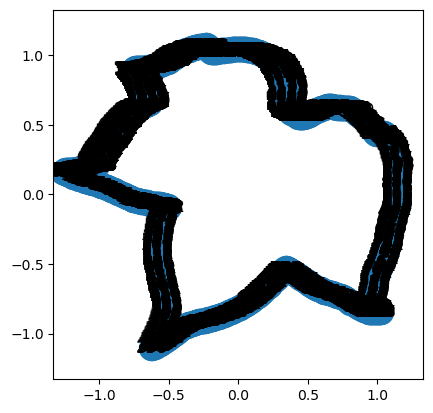

In [60]:
# Add edges to the graph according to the outline order.
# The samples of this dataset all have coordinates listed in order of the outline of the leaf.
# Note that for other datasets where this isn't the case, a different method must be used to define the graph structure.
for i in range(np.shape(leaf)[0]-1):
    G.add_edge(i, i+1)
G.add_edge(0,np.shape(leaf)[0]-1)

G.plot()

In [61]:
# initialize the ECT object using 32 directions and 48 thresholds
myect = ECT(num_dirs = 32, num_thresh=48)
print(f'Directions chosen are: {myect.thetas}')

Directions chosen are: [0.         0.19634954 0.39269908 0.58904862 0.78539816 0.9817477
 1.17809725 1.37444679 1.57079633 1.76714587 1.96349541 2.15984495
 2.35619449 2.55254403 2.74889357 2.94524311 3.14159265 3.33794219
 3.53429174 3.73064128 3.92699082 4.12334036 4.3196899  4.51603944
 4.71238898 4.90873852 5.10508806 5.3014376  5.49778714 5.69413668
 5.89048623 6.08683577]


In [62]:
# Set the bounding radius to be the global dataset bounding radius
global_bound_radius = 2.9092515639765497 # [TO DO]: compute the dataset global radius within ect package
myect.set_bounding_radius(global_bound_radius)
print(f'Set radius is: {myect.bound_radius}')
# Now the thresholds are set.
print(f'Thresholds chosen are: {myect.threshes}')

Set radius is: 2.9092515639765497
Thresholds chosen are: [-2.90925156 -2.78545363 -2.66165569 -2.53785775 -2.41405981 -2.29026187
 -2.16646393 -2.04266599 -1.91886805 -1.79507011 -1.67127218 -1.54747424
 -1.4236763  -1.29987836 -1.17608042 -1.05228248 -0.92848454 -0.8046866
 -0.68088866 -0.55709073 -0.43329279 -0.30949485 -0.18569691 -0.06189897
  0.06189897  0.18569691  0.30949485  0.43329279  0.55709073  0.68088866
  0.8046866   0.92848454  1.05228248  1.17608042  1.29987836  1.4236763
  1.54747424  1.67127218  1.79507011  1.91886805  2.04266599  2.16646393
  2.29026187  2.41405981  2.53785775  2.66165569  2.78545363  2.90925156]


In [63]:
# Calculate the ECT using the directions and thresholds specified by myect object
myect.calculateECT(G)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [67]:
# The saved ECT matrix
M = myect.get_ECT()
print(f'M has shape: {M.shape}')


# save the ECT matrix as a numpy file
output_filedir = os.path.join(mypath_output+ input_filedir[len(mypath):])
Path(os.path.dirname(output_filedir)).mkdir(parents=True, exist_ok=True)
print(f'Saving the ECT of sample as: {output_filedir} ...')
np.save(output_filedir, M)

M has shape: (32, 48)
Saving the ECT of sample as: data/ect/Cotton/1a_868a.npy ...


### Now perform the same  process on all of the samples of the dataset, computing the ECT, and saving the output matrix.

In [68]:
mypath = 'data/outlines/'
mypath_output = 'data/ect/'


# loop through file system
classes=[]
class_count = 0
for path, subdirs, files in os.walk(mypath):
    classes.extend(subdirs)
    files = [f for f in files if not f[0] == '.']
    subdirs[:] = [d for d in subdirs if (d[0] != '.')]
    print('Computing ECT of files in ', path, '...')
    print("There are ",len(files), ' samples to load in this directory.')
    
    for name in files:
        input_filedir = os.path.join(path, name)
        leaf = np.load(input_filedir)
        
        # Define a graph object for the leaf
        G = EmbeddedGraph()

        # Use coordinates of the leaf outline points to add vertices (and embedding coordinates) to the graph object
        valuesX = leaf[:,0]
        valuesY = leaf[:,1]
        for i in range(np.shape(leaf)[0]):
            G.add_node(i,valuesX[i],valuesY[i])

        # Add edges to the graph according to the outline order
        for i in range(np.shape(leaf)[0]-1):
            G.add_edge(i, i+1)
        G.add_edge(0,np.shape(leaf)[0]-1)
        
        # initialize the ECT object using 32 directions and 48 thresholds
        myect = ECT(num_dirs = 32, num_thresh=48)

        # Set the bounding radius to be the global dataset bounding radius
        # TO DO: compute the dataset global radius within ect package
        global_bound_radius = 2.9092515639765497
        myect.set_bounding_radius(global_bound_radius)

        myect.calculateECT(G)

        # The saved ECT matrix
        M = myect.get_ECT()


        # save the ECT matrix as a numpy file
        output_filedir = os.path.join(mypath_output+ input_filedir[len(mypath):])
        Path(os.path.dirname(output_filedir)).mkdir(parents=True, exist_ok=True)
        np.save(output_filedir, M)
        
        
    print('Saving the ECT of directory in ', path, '...')


Computing ECT of files in  data/outlines/ ...
There are  0  samples to load in this directory.
Saving the ECT of directory in  data/outlines/ ...
Computing ECT of files in  data/outlines/Ivy ...
There are  30  samples to load in this directory.
Saving the ECT of directory in  data/outlines/Ivy ...
Computing ECT of files in  data/outlines/Cotton ...
There are  30  samples to load in this directory.
Saving the ECT of directory in  data/outlines/Cotton ...


### Now we have a saved dataset consisting of ECT matrices for the leaf outline dataset. We can train various models using these ECT matrices. Here, we show an example using a Convolutional Neural Network (CNN) to perform binary classification between the "Cotton" and "Ivy" classes.

# Train a CNN model on the ECT images

In [3]:
import torch
import argparse
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

In [4]:
# This is the CNN model class we will use for classification, defined in models.py
# Within this class, we specify the kernel size parameter. 
from models import CNN 

In [5]:
# These functions allow us to define datasets and load them into PyTorch.
# The dataset classes and data loaders can be adjusted in dataloaders.py
from dataloaders import create_datasets, create_data_loaders
from utils import save_model, save_plots, save_cf, SaveBestModel

In [19]:
# Model training parameters:

NUM_EPOCHS = 50 # number of epochs to train the network for; type=int
#BATCH_SIZE = 4 # batch size for dataloaders; type=int
LEARNING_RATE = 1e-3 # learning rate for training; type=float

In [20]:
# device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Computation device: cpu



### Load in the dataset and split into training and test datasets

In [21]:
# build train and test datasets
train_dataset, test_dataset = create_datasets()

# get the training and test data loaders
train_loader, test_loader = create_data_loaders(train_dataset, test_dataset)

/Users/sarahmcguire/Library/CloudStorage/Dropbox/MSU/DirectionalTransformNN/2Dproject/Tutorial/data/ect/
['Ivy', 'Cotton']
num_classes= 2
ECT data; using only normalize, rotation transforms on training data


In [22]:
# show a few samples from the training dataset
trainimages, trainlabels = next(iter(train_loader))
print(f'The tensor shape of each batch in the training dataset is \n[batch_size, num_channels, num_directions, num_thresholds]: {trainimages.shape}')

The tensor shape of each batch in the training dataset is 
[batch_size, num_channels, num_directions, num_thresholds]: torch.Size([4, 1, 32, 48])


training images


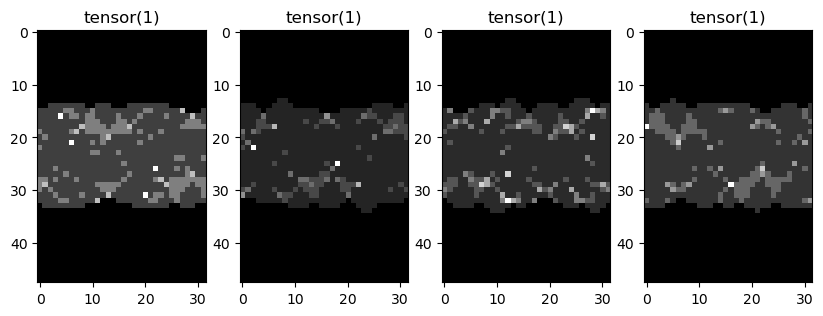

The labels for this example batch are tensor([1, 1, 1, 1]), where 0 indicates Ivy and 1 indicates Cotton


In [23]:
plt.style.use('default')
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
print('training images')
for i in range(4):
    ax = axes[i]
    ax.imshow(trainimages[i,0,:,:].T, cmap='gray')
    ax.set_title(trainlabels[i])
plt.show()

print(f'The labels for this example batch are {trainlabels}, where 0 indicates Ivy and 1 indicates Cotton')

In [24]:
# function to train the  model and keep track of loss and accuracy
def train(model, train_loader, optimizer, lossfcn):
    model.train()
    print('Training')
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    for i, data in tqdm(enumerate(train_loader), total=len(train_loader)):
        counter += 1
        image, labels = data
        image = image.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        # forward pass
        outputs = model(image)
        # calculate the loss
        loss = lossfcn(outputs, labels)
        train_running_loss += loss.item()
        # calculate the accuracy
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == labels).sum().item()
        # backpropagation
        loss.backward()
        # update the optimizer parameters
        optimizer.step()
    
    # loss and accuracy for the complete epoch
    epoch_loss = train_running_loss / counter
    epoch_acc = 100. * (train_running_correct / len(train_loader.dataset))
    return epoch_loss, epoch_acc

In [25]:
# function for validation
def validate(model, valid_loader, lossfcn):
    model.eval()
    print('Validation')
    valid_running_loss = 0.0
    valid_running_correct = 0
    counter = 0
    with torch.no_grad():
        outputs_list = []
        labels_list = []
        for i, data in tqdm(enumerate(valid_loader), total=len(valid_loader)):
            counter += 1
            
            image, labels = data
            image = image.to(device)
            labels = labels.to(device)
            # forward pass
            outputs = model(image)
            outputs_list.append(outputs)
            labels_list.append(labels)
            # calculate the loss
            loss = lossfcn(outputs, labels)
            valid_running_loss += loss.item()
            # calculate the accuracy
            _, preds = torch.max(outputs.data, 1)
            valid_running_correct += (preds == labels).sum().item()
        
    # loss and accuracy for the complete epoch
    epoch_loss = valid_running_loss / counter
    epoch_acc = 100. * (valid_running_correct / len(valid_loader.dataset))

    return epoch_loss, epoch_acc

In [26]:
# specify the model to be used for training
model = CNN(num_classes=train_dataset.num_classes, num_channels=trainimages.shape[1]).to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1920, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=2, bias=True)
)


In [27]:
# total parameters and trainable parameters for the model
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")

1,971,074 total parameters.
1,971,074 training parameters.



In [28]:
# optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
# loss function
lossfcn = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

In [29]:
# keeping track of losses and accuracies
train_loss, valid_loss = [],[]
train_acc, valid_acc = [],[]

# begin training
for epoch in range(1,NUM_EPOCHS+1):
    print(f"[INFO]: Epoch {epoch} of {NUM_EPOCHS}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, optimizer, lossfcn)
    valid_epoch_loss, valid_epoch_acc = validate(model, test_loader, lossfcn)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")

    # save the best model up to current epoch, if we have the least loss in the current epoch
    save_best_model(
        valid_epoch_loss, epoch, model, optimizer, lossfcn
    )
    print('-'*50)
    

[INFO]: Epoch 1 of 50
Training


  0%|          | 0/12 [00:00<?, ?it/s]

Validation


  0%|          | 0/3 [00:00<?, ?it/s]

Training loss: 0.775, training acc: 52.083
Validation loss: 0.676, validation acc: 58.333

Best validation loss: 0.6757877469062805

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 50
Training


...

Training loss: 0.158, training acc: 95.833
Validation loss: 0.088, validation acc: 100.000

Best validation loss: 0.08754108535746734

Saving best model for epoch: 49

--------------------------------------------------
[INFO]: Epoch 50 of 50
Training


  0%|          | 0/12 [00:00<?, ?it/s]

Validation


  0%|          | 0/3 [00:00<?, ?it/s]

Training loss: 0.166, training acc: 93.750
Validation loss: 0.354, validation acc: 83.333
--------------------------------------------------


Saving final model...


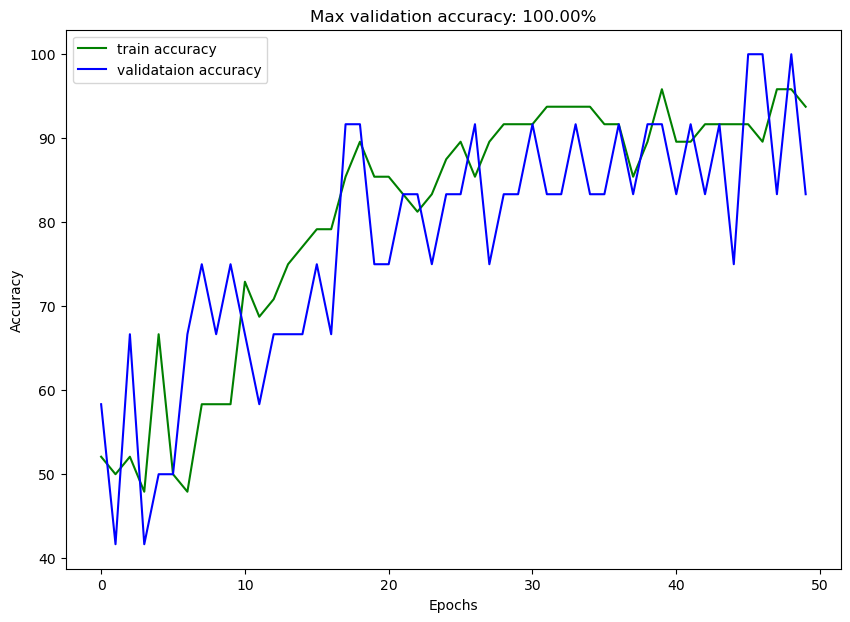

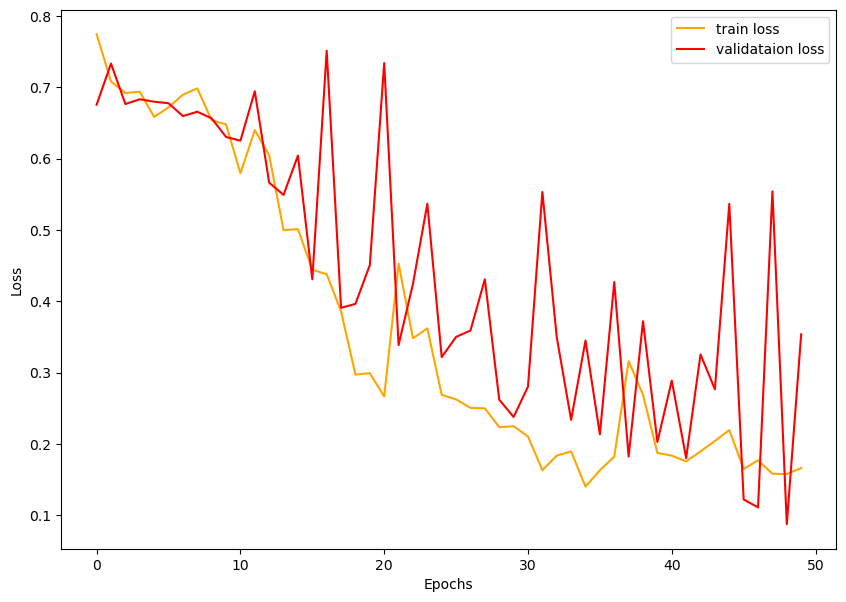

In [30]:
# save the trained model weights for a final time
save_model(NUM_EPOCHS, model, optimizer, lossfcn)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss)

Using validation to compute confusion matrix


  0%|          | 0/3 [00:00<?, ?it/s]

classes: ['Ivy', 'Cotton']
Test Result:
Accuracy Score: 100.00%
_______________________________________________
CLASSIFICATION REPORT:
             0    1  accuracy  macro avg  weighted avg
precision  1.0  1.0       1.0        1.0           1.0
recall     1.0  1.0       1.0        1.0           1.0
f1-score   1.0  1.0       1.0        1.0           1.0
support    7.0  5.0       1.0       12.0          12.0
_______________________________________________
Confusion Matrix: 
 [[7 0]
 [0 5]]



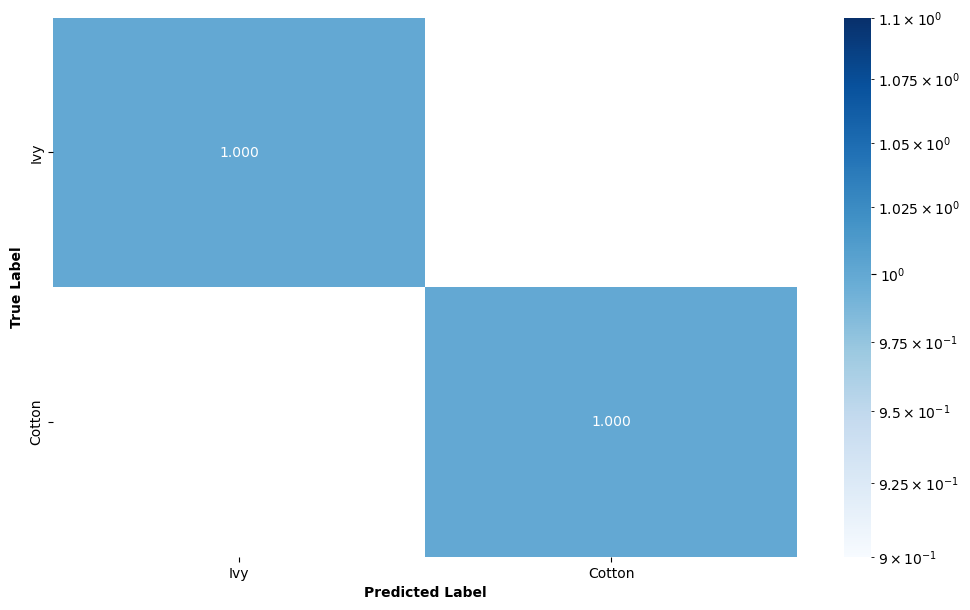

In [34]:
# save confusion matrix of best model
# model, valid_loader, lossfcn
model = CNN(num_classes=train_dataset.num_classes, num_channels=trainimages.shape[1])

state_dict = torch.load('outputs/best_model.pth')['model_state_dict']
model.load_state_dict(state_dict)
model.eval()
print('Using validation to compute confusion matrix')
valid_running_pred = []
valid_running_labels = []
counter = 0
with torch.no_grad():
    for i, data in tqdm(enumerate(test_loader), total=len(test_loader)):
        counter += 1
        
        image, labels = data
        image = image.to(device)
        labels = labels.to(device)
        # forward pass
        outputs = model(image)
        # calculate the accuracy
        _, preds = torch.max(outputs.data, 1)

        valid_running_pred.append(preds)
        valid_running_labels.append(labels)
    
# confusion matrix for the complete epoch
valid_running_pred = torch.cat(valid_running_pred)
valid_running_labels = torch.cat(valid_running_labels)
print('classes:',test_dataset.classes)
save_cf(valid_running_pred,valid_running_labels, test_dataset.classes)
